## LangGraph로 만드는 Agentic RAG

<div style="text-align: right"> <b>KMYU</b></div>
<div style="text-align: right"> Initial issue : 2026.06.23 </div>
<div style="text-align: right"> last update : 2026.06.23 </div>

개정 이력  
- `2026.06.23` : 노트북 최초 작성

### 왜 LangGraph인가?

`2.3_agentic_rag.ipynb` 에서는 `create_agent` **한 줄** 로 Agentic RAG 에이전트를 만들었습니다.

```python
agent = create_agent(model=..., tools=[...], system_prompt=...)
```

편하지만, 에이전트가 *속으로* 돌리는 **ReAct 루프** 는 보이지 않았습니다. 즉 다음 흐름이 **블랙박스** 안에 숨어 있었죠.

> 질문 → **[판단]** 도구를 쓸까? → 도구 호출 → **결과 관찰** → 다시 판단 → … → 최종 답변

이 노트북에서는 **완전히 똑같은 기능** (같은 문서·벡터DB·도구·시나리오)을 **LangGraph 의 `StateGraph`** 로 *직접 조립* 해, 그 숨겨진 루프를 **노드(node)와 엣지(edge)로 눈에 보이게** 만듭니다.

```
        ┌─────────┐   도구 호출 있음   ┌────────┐
START → │  agent  │ ───────────────→ │  tools │
        └─────────┘                  └────────┘
             │  ▲                          │
  도구 호출   │  └──────────────────────────┘
  없음        ▼        (결과 관찰 후 다시 판단)
           END
```

- **`agent` 노드** : LLM이 질문을 보고 *"도구를 쓸지, 어떤 도구를 쓸지"* 를 판단한다.
- **`tools` 노드** : 에이전트가 고른 도구를 실제로 실행한다. (`ToolNode`)
- **조건부 엣지** : 에이전트가 도구를 호출했으면 `tools` 로, 아니면 `END` 로 분기한다. (`tools_condition`)

기능은 `2.3` 과 동일합니다. 달라지는 것은 **제어권과 가시성** 입니다. `create_agent` 가 대신 돌려주던 루프를, 우리가 직접 그리고 제어합니다.

### 0. 환경 설정

In [1]:
import os

from dotenv import load_dotenv

load_dotenv()

True

In [2]:
print("LLM       :", os.getenv("ANTHROPIC_MODEL"))
print("Embedding :", os.getenv("VOYAGE_EMBEDDING_MODEL"))

LLM       : claude-haiku-4-5
Embedding : voyage-4-lite


### 1. 벡터 DB 로드 → retriever

`2.1` 에서 저장하고 `2.2`·`2.3` 에서 불러왔던 FAISS 인덱스를 **똑같이** 불러옵니다. (임베딩 모델은 저장할 때와 같은 `voyage-4-lite` 를 써야 합니다.)

여기까지는 `2.3` 과 완전히 동일합니다. retriever 를 만든 뒤, 다음 단계에서 **에이전트가 쓸 수 있는 도구로 감쌀** 것입니다.

In [3]:
import time

from langchain_voyageai import VoyageAIEmbeddings
from langchain_community.vectorstores import FAISS

class RateLimitedVoyageEmbeddings(VoyageAIEmbeddings):
    """무료 한도(3 RPM / 10K TPM) 초과 시 잠시 대기 후 자동 재시도하는 임베딩.

    RateLimitError 가 나면 25초 기다렸다가 다시 시도하므로,
    빌드·검색 어디서 호출되든 한도에 걸려도 알아서 통과한다.
    (근본 해결은 결제수단 등록 — 무료 토큰은 그대로 적용된다.)
    """

    def _with_retry(self, fn, arg):
        for attempt in range(6):
            try:
                return fn(arg)
            except Exception as e:
                if "RateLimit" not in type(e).__name__:
                    raise
                print(f"  [rate limit] 25초 대기 후 재시도 ({attempt + 1}/6)")
                time.sleep(25)
        raise RuntimeError("재시도 초과 - 잠시 후 다시 실행하거나 결제수단을 등록하세요.")

    def embed_documents(self, texts):
        return self._with_retry(super().embed_documents, texts)

    def embed_query(self, text):
        return self._with_retry(super().embed_query, text)


embeddings = RateLimitedVoyageEmbeddings(model=os.getenv("VOYAGE_EMBEDDING_MODEL"))

vectorstore = FAISS.load_local(
    "../data/vector_db/osh_act_faiss",
    embeddings,
    allow_dangerous_deserialization=True,
)

retriever = vectorstore.as_retriever(search_kwargs={"k": 3})
print("벡터 DB 로드 완료")

벡터 DB 로드 완료


### 2. 도구(Tool) 만들기

에이전트가 골라 쓸 도구 세 개를 준비합니다. `2.3` 과 **똑같은 도구** 입니다. LangGraph 로 바꿔도 *도구의 정의는 그대로* 라는 점에 주목하세요.

`@tool` 데코레이터를 붙이고, **독스트링(설명문)** 에 *"언제 이 도구를 써야 하는지"* 를 분명히 적는 것이 핵심입니다. 에이전트(`agent` 노드의 LLM)는 이 설명만 읽고 도구를 고릅니다.

#### 2-1. 검색 도구 — RAG를 '도구'로 감싸기

retriever 를 **`@tool` 로 감싸** 에이전트가 *필요할 때만* 부르게 만듭니다. 독스트링에 **"산업안전보건법·안전·보건 관련 질문일 때 쓰라"** 고 명시하는 것이 라우팅(도구 선택)의 판단 근거가 됩니다. 또한 검색 결과에 **페이지 번호** 를 붙여 돌려주어, 답변에 출처를 함께 밝힐 수 있게 합니다.

In [4]:
from langchain.tools import tool


@tool
def search_osh_act(query: str) -> str:
    """산업안전보건법 문서에서 질문과 관련된 조항을 검색한다.

    산업안전·보건, 사업주/근로자의 의무, 중대재해, 도급, 작업중지,
    안전보건진단 등 '법령·안전' 관련 질문일 때 사용한다.
    검색된 조항 본문을 (페이지 번호와 함께) 돌려준다.
    """
    docs = retriever.invoke(query)
    return "\n\n".join(
        f"(p.{doc.metadata.get('page')}) {doc.page_content}" for doc in docs
    )

#### 2-2. 날짜·날씨 도구

`1.3`·`2.3` 에서 쓰던 `get_today` 와 `get_weather` 를 그대로 가져옵니다. 검색 도구와 **나란히** 두면, *법령 질문이 아닌* 질문이 들어왔을 때 에이전트가 검색 대신 이 도구들을 고르는 모습을 확인할 수 있습니다. (날씨는 실제 API 대신 **목업** 으로 서울 = 맑음 고정)

In [5]:
from datetime import date


@tool
def get_today() -> str:
    """오늘 날짜를 'YYYY년 MM월 DD일' 형식으로 알려준다."""
    return date.today().strftime("%Y년 %m월 %d일")


@tool
def get_weather(city: str) -> str:
    """도시 이름을 입력받아 오늘 그 도시의 날씨를 알려준다. (실습용 목업 데이터)"""
    weather_db = {
        "서울": "맑음 (최고 24도 / 최저 14도)",
    }
    return weather_db.get(city, f"'{city}'의 날씨 정보가 없습니다.")

### 3. 시스템 프롬프트 설계

`2.3` 과 **똑같은 시스템 프롬프트** 를 씁니다. Agentic RAG에서 프롬프트는 **"어떤 상황에 어떤 도구를 쓰고, 결과를 어떻게 다룰지"에 대한 규칙서** 입니다.

- **페르소나 / 도구 카탈로그** : 어떤 역할이며, 어떤 도구가 있고 각각 언제 쓰는지
- **라우팅 규칙** : 법령 질문 → 검색, 날짜·날씨 → 해당 도구, 잡담 → 도구 없이 답변
- **그라운딩 규칙** : 검색 결과로 답할 땐 *문서 내용만* 근거로 하고, 근거가 없으면 솔직히 "찾을 수 없다"고 답한다. (환각 방지)
- **출력 형식** : 한국어로, 가능하면 **근거 조항·페이지** 를 함께 제시

> ⚠️ `2.3` 의 `create_agent` 는 이 프롬프트를 알아서 매 호출 앞에 끼워 넣어 줬습니다. **LangGraph 에서는 우리가 직접** `agent` 노드 안에서 메시지 맨 앞에 붙여야 합니다. (5단계에서 확인)

In [6]:
agentic_rag_prompt = """너는 '산업안전보건법'과 생활 정보를 함께 도와주는 한국어 어시스턴트야.

[사용할 수 있는 도구]
- search_osh_act : 산업안전보건법 문서에서 관련 조항을 검색한다.
    → 산업안전·보건, 사업주/근로자 의무, 중대재해, 도급, 작업중지, 안전보건진단 등
      '법령·안전' 관련 질문에 사용한다.
- get_today : 오늘 날짜를 알려준다.
- get_weather : 특정 도시의 오늘 날씨를 알려준다.

[행동 규칙]
1. 먼저 질문에 어떤 정보가 필요한지, 어떤 도구를 써야 할지 생각한다.
2. 산업안전보건법·안전·보건 관련 질문이면 반드시 search_osh_act 로 근거를 찾는다.
   너의 사전지식이나 추측으로 답하지 않는다.
3. search_osh_act 결과로 답할 때는 검색된 문서 내용만 근거로 삼는다.
   문서에서 근거를 찾을 수 없으면 "제공된 문서에서 해당 내용을 찾을 수 없습니다." 라고 솔직히 답한다.
4. 날짜·날씨는 추측하지 말고 반드시 도구를 호출해 확인한다.
5. 인사·잡담처럼 도구가 필요 없는 질문은 도구를 호출하지 말고 바로 답한다.
6. 답변은 한국어로, 핵심을 먼저 간결하게 말한다.
   법령 답변은 가능하면 근거 조항(예: 제5조)이나 페이지를 함께 밝힌다.
"""

print(agentic_rag_prompt)

너는 '산업안전보건법'과 생활 정보를 함께 도와주는 한국어 어시스턴트야.

[사용할 수 있는 도구]
- search_osh_act : 산업안전보건법 문서에서 관련 조항을 검색한다.
    → 산업안전·보건, 사업주/근로자 의무, 중대재해, 도급, 작업중지, 안전보건진단 등
      '법령·안전' 관련 질문에 사용한다.
- get_today : 오늘 날짜를 알려준다.
- get_weather : 특정 도시의 오늘 날씨를 알려준다.

[행동 규칙]
1. 먼저 질문에 어떤 정보가 필요한지, 어떤 도구를 써야 할지 생각한다.
2. 산업안전보건법·안전·보건 관련 질문이면 반드시 search_osh_act 로 근거를 찾는다.
   너의 사전지식이나 추측으로 답하지 않는다.
3. search_osh_act 결과로 답할 때는 검색된 문서 내용만 근거로 삼는다.
   문서에서 근거를 찾을 수 없으면 "제공된 문서에서 해당 내용을 찾을 수 없습니다." 라고 솔직히 답한다.
4. 날짜·날씨는 추측하지 말고 반드시 도구를 호출해 확인한다.
5. 인사·잡담처럼 도구가 필요 없는 질문은 도구를 호출하지 말고 바로 답한다.
6. 답변은 한국어로, 핵심을 먼저 간결하게 말한다.
   법령 답변은 가능하면 근거 조항(예: 제5조)이나 페이지를 함께 밝힌다.



### 4. LLM에 도구 바인딩 ⭐ (2.3과 갈리는 지점)

`2.3` 의 `create_agent` 는 *모델 생성 → 도구 바인딩 → 루프 실행* 을 한 번에 처리해 줬습니다. LangGraph 에서는 이 과정을 **우리가 직접** 합니다. 그 첫 단추가 **도구 바인딩** 입니다.

`llm.bind_tools(tools)` 는 LLM 에게 *"이런 도구들을 쓸 수 있어"* 라고 알려 줍니다. 이렇게 바인딩된 LLM은 답변 대신 **"이 도구를 이런 인자로 불러줘"(tool_calls)** 를 내놓을 수 있게 됩니다. 이 `tool_calls` 가 있는지 없는지가 뒤에서 그래프의 분기 기준이 됩니다.

In [7]:
from langchain.chat_models import init_chat_model

llm = init_chat_model(model=os.getenv("ANTHROPIC_MODEL"), temperature=0)

tools = [search_osh_act, get_today, get_weather]

# LLM에 도구 목록을 알려준다 → 이제 LLM은 필요하면 tool_calls를 만들어 낸다.
llm_with_tools = llm.bind_tools(tools)
print("도구 바인딩 완료:", [t.name for t in tools])

도구 바인딩 완료: ['search_osh_act', 'get_today', 'get_weather']


### 5. 그래프 구성 ⭐ (핵심)

이제 ReAct 루프를 **그래프로 직접 조립** 합니다. 구성 요소는 세 가지입니다.

1. **State** : 그래프가 단계마다 주고받는 데이터. 여기서는 *대화 메시지 목록* 하나면 충분합니다 → `MessagesState`
2. **노드(node)** : 실제 일을 하는 함수. `agent`(LLM 판단)와 `tools`(도구 실행) 두 개를 둡니다.
3. **엣지(edge)** : 노드 사이의 연결. 특히 *조건부 엣지* 로 "도구를 쓸지 / 끝낼지"를 분기합니다.

#### 5-1. State 정의 — `MessagesState`

LangGraph 가 기본 제공하는 `MessagesState` 는 `messages` 라는 메시지 리스트 한 칸을 가진 상태입니다. 노드가 `{"messages": [새 메시지]}` 를 반환하면, **덮어쓰지 않고 리스트 뒤에 자동으로 누적** 됩니다(add_messages reducer). 덕분에 *질문 → 도구호출 → 도구결과 → 답변* 이 한 대화로 차곡차곡 쌓입니다.

In [8]:
from langgraph.graph import StateGraph, MessagesState, START, END

#### 5-2. `agent` 노드 — LLM이 판단하는 곳

`agent` 노드는 *지금까지의 대화* 를 받아 **도구를 바인딩한 LLM** 에게 넘기고, 그 응답(답변이거나 `tool_calls`)을 상태에 추가합니다.

여기서 `2.3` 과의 결정적 차이가 드러납니다. **시스템 프롬프트를 우리가 직접** 메시지 맨 앞에 붙여 줍니다. `create_agent` 가 자동으로 해 주던 일을, 노드 함수 안에서 명시적으로 처리하는 것입니다.

In [9]:
from langchain_core.messages import SystemMessage


def agent_node(state: MessagesState) -> dict:
    """대화 메시지를 LLM에 넘겨 '다음 행동'(도구 호출 또는 최종 답변)을 결정한다."""
    # create_agent와 달리, 시스템 프롬프트를 매번 직접 맨 앞에 끼워 넣어야 한다.
    messages = [SystemMessage(content=agentic_rag_prompt)] + state["messages"]
    response = llm_with_tools.invoke(messages)
    # 반환값은 messages 리스트에 '누적'된다 (add_messages).
    return {"messages": [response]}

#### 5-3. `tools` 노드 & 분기 — `ToolNode`, `tools_condition`

LangGraph 가 미리 만들어 둔 두 부품을 씁니다. 직접 구현할 수도 있지만, ReAct의 정석 동작이라 프레임워크가 제공합니다.

- **`ToolNode(tools)`** : 직전 `agent` 응답에 담긴 `tool_calls` 를 읽어, 해당 도구를 *실제로 실행* 하고 그 결과를 `ToolMessage` 로 상태에 추가한다.
- **`tools_condition`** : 직전 `agent` 응답을 보고 분기를 결정하는 함수. **`tool_calls` 가 있으면 `"tools"`** 로, **없으면 `END`** 로 보낸다. → 즉 "도구를 쓸지 / 그냥 끝낼지"를 자동 판정한다.

In [10]:
from langgraph.prebuilt import ToolNode, tools_condition

tool_node = ToolNode(tools)

#### 5-4. 그래프 조립 & 컴파일

이제 노드와 엣지를 연결합니다. 아래 다섯 줄이 곧 **ReAct 루프** 입니다.

- `START → agent` : 질문이 들어오면 먼저 에이전트가 판단한다.
- `agent → (조건부) → tools 또는 END` : 도구가 필요하면 실행하러 가고, 아니면 끝낸다.
- `tools → agent` : 도구 결과를 **다시 에이전트에게** 돌려준다 → 결과를 관찰하고 한 번 더 판단(추가 도구 호출 또는 최종 답변). **이 되돌아오는 엣지가 '루프'를 만든다.**

In [11]:
graph = StateGraph(MessagesState)

# 1) 노드 등록
graph.add_node("agent", agent_node)
graph.add_node("tools", tool_node)

# 2) 엣지 연결
graph.add_edge(START, "agent")              # 시작 → 에이전트 판단
graph.add_conditional_edges(                 # 에이전트 판단 → 분기
    "agent",
    tools_condition,                         # tool_calls 있으면 "tools", 없으면 END
)
graph.add_edge("tools", "agent")            # 도구 결과 관찰 후 다시 판단 (루프!)

# 3) 컴파일 → 실행 가능한 앱
app = graph.compile()
print("그래프 컴파일 완료")

그래프 컴파일 완료


### 6. 그래프 구조 시각화

`2.3` 에서는 볼 수 없었던 **루프 구조** 를 LangGraph 는 그림으로 보여 줍니다. `agent` 와 `tools` 두 노드, 그리고 `agent`→`tools`→`agent` 로 도는 루프와 `agent`→`END` 분기를 확인하세요.

(PNG 렌더링은 네트워크/graphviz 환경에 따라 실패할 수 있어, 의존성 없는 **텍스트(mermaid)** 출력을 항상 함께 둡니다.)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	agent(agent)
	tools(tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> agent;
	agent -.-> __end__;
	agent -.-> tools;
	tools --> agent;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



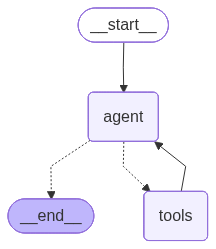

In [12]:
# 1) 텍스트(mermaid) — 항상 출력된다
print(app.get_graph().draw_mermaid())

# 2) 그림(PNG) — 가능한 환경에서만 표시 (실패해도 노트북은 멈추지 않음)
try:
    from IPython.display import Image, display

    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"\n[PNG 렌더링 건너뜀] {type(e).__name__}: 위 mermaid 텍스트로 구조를 확인하세요.")

### 7. 추론·도구 호출 과정 출력하기

에이전트가 주고받은 **모든 메시지** 를 순서대로 출력하는 헬퍼를 `2.3` 에서 그대로 가져옵니다. 컴파일된 그래프 `app.invoke(...)` 도 `2.3` 과 **똑같은 `result["messages"]` 형태** 를 돌려주므로, 출력 코드는 거의 바뀌지 않습니다.

- `[모델의 생각 / 답변]` : 모델이 작성한 추론 또는 최종 답
- `[도구 호출]` : 모델이 **어떤 도구를 어떤 인자로** 호출했는지
- `[도구 결과]` : 도구가 돌려준 값

In [13]:
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage


def _to_text(content) -> str:
    """메시지 content가 문자열이든 블록 리스트든 텍스트만 뽑아낸다."""
    if isinstance(content, str):
        return content
    chunks = []
    for block in content or []:
        if isinstance(block, str):
            chunks.append(block)
        elif isinstance(block, dict) and block.get("type") == "text":
            chunks.append(block.get("text", ""))
    return "".join(chunks)


def run_graph(app, question):
    """그래프를 실행하고 추론·도구 호출·도구 결과·최종 답변을 순서대로 출력한다."""
    result = app.invoke({"messages": [HumanMessage(content=question)]})

    for msg in result["messages"]:
        if isinstance(msg, HumanMessage):
            print("[사용자 질문]")
            print(msg.content)
        elif isinstance(msg, AIMessage):
            text = _to_text(msg.content)
            if text.strip():
                print("[모델의 생각 / 답변]")
                print(text)
            for call in msg.tool_calls:
                print(f"[도구 호출] {call['name']} (인자: {call['args']})")
        elif isinstance(msg, ToolMessage):
            print(f"[도구 결과] {msg.name} → {msg.content[:200]}")
        print("-" * 60)

    return result

### 8. 시나리오 비교 — 그래프는 질문에 따라 다른 경로를 탄다

`2.3` 과 **똑같은 다섯 가지 질문** 을 던집니다. 같은 그래프인데도 질문에 따라 `agent → tools → agent` 루프를 돌기도 하고, 곧장 `agent → END` 로 끝나기도 합니다. 결과가 `2.3` 과 동일한지 비교하며, 이번에는 *어떤 경로를 탔는지* 까지 눈으로 확인하세요.

#### 시나리오 A — 안전·법령 질문 → 검색 도구 호출

산업안전보건법 관련 질문입니다. `agent` 가 `search_osh_act` 를 호출(→ `tools` 노드 실행) → 결과를 받아 다시 `agent` 로 돌아와 답을 만드는, **루프를 한 바퀴 도는** 경로를 확인합니다.

In [14]:
_ = run_graph(app, "근로자의 의무는 무엇인가요?")

[사용자 질문]
근로자의 의무는 무엇인가요?
------------------------------------------------------------
[모델의 생각 / 답변]
근로자의 의무에 대해 산업안전보건법에서 찾아보겠습니다.
[도구 호출] search_osh_act (인자: {'query': '근로자의 의무'})
------------------------------------------------------------
[도구 결과] search_osh_act → (p.12) 작업장소에서 대피시키는 등 안전 및 보건에 관하여 필요한 조치를 하여야 한다.
 
제52조(근로자의 작업중지) ① 근로자는 산업재해가 발생할 급박한 위험이 있는 경우에는 작업을 중지하고 대피할 수
있다.
② 제1항에 따라 작업을 중지하고 대피한 근로자는 지체 없이 그 사실을 관리감독자 또는 그 밖에 부서의 장(이하
“관리감독자등”이라 한다)에게
------------------------------------------------------------
[모델의 생각 / 답변]
**근로자의 의무**는 산업안전보건법 제6조에 명시되어 있습니다:

## 주요 의무 (제6조)
근로자는 다음을 지켜야 합니다:
1. **법령 준수**: 산업안전보건법과 이에 따른 명령으로 정하는 산업재해 예방 기준을 지켜야 함
2. **조치 이행**: 사업주, 노동감독관, 공단 등 관계인이 실시하는 산업재해 예방 조치에 따라야 함

## 추가 의무

**제40조 - 안전·보건조치 준수**
- 사업주가 한 안전조치 및 보건조치 사항을 지켜야 함

**제52조 - 작업중지 및 보고**
- 산업재해가 발생할 급박한 위험이 있는 경우 작업을 중지하고 대피할 수 있음
- 작업을 중지하고 대피한 후 지체 없이 관리감독자 등에게 보고해야 함

**제41조 - 고객응대 관련**
- 고객의 폭언 등으로 인한 건강장해 발생 시 사업주에게 조치를 요구할 수 있음

근로자의 의무는 기본적으로 **안전보건 기준을 지키고 사업주의 

#### 시나리오 B — 날씨 질문 → 검색 도구는 부르지 않는다

안전·법령과 무관한 날씨 질문입니다. `search_osh_act` 는 부르지 않고 `get_weather` 만 골라 쓰는지 확인하세요. (검색이 *항상* 일어나지 않는 것이 Agentic RAG의 핵심)

In [15]:
_ = run_graph(app, "오늘 서울 날씨 어때?")

[사용자 질문]
오늘 서울 날씨 어때?
------------------------------------------------------------
[모델의 생각 / 답변]
오늘 서울의 날씨를 확인해드리겠습니다.
[도구 호출] get_weather (인자: {'city': '서울'})
------------------------------------------------------------
[도구 결과] get_weather → 맑음 (최고 24도 / 최저 14도)
------------------------------------------------------------
[모델의 생각 / 답변]
오늘 서울은 **맑음**이며, 최고 기온은 **24도**, 최저 기온은 **14도**입니다. 쾌적한 날씨네요! 😊
------------------------------------------------------------


#### 시나리오 C — 복합 질문 → 여러 도구를 함께 사용

성격이 다른 두 가지를 한 번에 물어봅니다. `agent` 가 `get_today`(날짜)와 `search_osh_act`(법령)를 **모두** 골라 쓰며 답을 조립하는 과정을 살펴보세요.

In [16]:
_ = run_graph(app, "오늘 날짜 알려주고, 사업주의 안전·보건 조치 의무도 알려줘.")

[사용자 질문]
오늘 날짜 알려주고, 사업주의 안전·보건 조치 의무도 알려줘.
------------------------------------------------------------
[모델의 생각 / 답변]
오늘 날짜와 사업주의 안전·보건 조치 의무를 알려드리겠습니다.
[도구 호출] get_today (인자: {})
[도구 호출] search_osh_act (인자: {'query': '사업주 안전 보건 조치 의무'})
------------------------------------------------------------
[도구 결과] get_today → 2026년 06월 29일
------------------------------------------------------------
[도구 결과] search_osh_act → (p.10) 법제처                                                            11                                                       국가법령정보센터
산업안전보건법
2. 방사선ㆍ유해광선ㆍ고열ㆍ한랭ㆍ초음파ㆍ소음ㆍ진동ㆍ이상기압 등에 의한 건강장해
3. 사업장에서 배출되
------------------------------------------------------------
[모델의 생각 / 답변]
## 오늘 날짜
**2026년 06월 29일**

---

## 사업주의 안전·보건 조치 의무

산업안전보건법 **제5조**에서 사업주의 의무를 규정하고 있습니다:

### 주요 의무 사항
사업주는 다음 사항을 이행함으로써 근로자의 안전 및 건강을 유지·증진시켜야 합니다:

1. **산업재해 예방 기준 준수**
   - 법과 법에 따른 명령으로 정하는 산업재해 예방 기준 준수

2. **쾌적한 작업환경 조성**
   - 근로자의 신체적 피로와 정신적 스트레스를 줄일 수 있는 쾌적한 작업환경 조성
   - 근로조건 개선

3. **정보 제공

#### 시나리오 D — 도구가 필요 없는 질문 → 바로 답변

인사나 자기소개 요청처럼 외부 정보가 필요 없는 질문입니다. `agent` 가 도구를 한 번도 호출하지 않고 **곧장 `agent → END`** 로 끝나는지 확인합니다. (불필요한 검색을 하지 않는 것도 좋은 에이전트의 능력입니다.)

In [17]:
_ = run_graph(app, "안녕? 너는 무슨 일을 도와줄 수 있어?")

[사용자 질문]
안녕? 너는 무슨 일을 도와줄 수 있어?
------------------------------------------------------------
[모델의 생각 / 답변]
안녕하세요! 👋

저는 다음 두 가지 분야에서 도움을 드릴 수 있습니다:

## 1️⃣ **산업안전보건법 관련 질문**
- 사업주와 근로자의 의무
- 산업안전·보건 기준
- 중대재해, 도급, 작업중지 등 안전 관련 규정
- 안전보건진단 등 법령·안전 관련 사항

예: *"근로자가 위험한 작업을 거부할 수 있나요?"*, *"사업주의 안전 의무는 뭔가요?"*

## 2️⃣ **생활 정보**
- **오늘 날짜** 확인
- **날씨 정보** (도시명 입력)

예: *"오늘 날짜가 뭐예요?"*, *"서울 날씨는 어때요?"*

---

궁금한 점이 있으시면 편하게 물어봐주세요! 😊
------------------------------------------------------------


#### 시나리오 E — 범위 밖 법령 질문 → 그라운딩으로 솔직하게

"연차 휴가" 는 근로기준법 영역이라 산업안전보건법 문서에는 없습니다. 에이전트가 검색해 보고 **근거가 없으면** 지어내지 말고 "찾을 수 없다"고 답해야 합니다. 그라운딩 규칙이 LangGraph 그래프에서도 그대로 작동하는지 확인합니다.

In [18]:
_ = run_graph(app, "근로자의 연차 휴가는 며칠인가요?")

[사용자 질문]
근로자의 연차 휴가는 며칠인가요?
------------------------------------------------------------
[모델의 생각 / 답변]
연차 휴가에 대해 산업안전보건법 문서에서 검색해드리겠습니다.
[도구 호출] search_osh_act (인자: {'query': '근로자 연차 휴가'})
------------------------------------------------------------
[도구 결과] search_osh_act → (p.12) 작업장소에서 대피시키는 등 안전 및 보건에 관하여 필요한 조치를 하여야 한다.
 
제52조(근로자의 작업중지) ① 근로자는 산업재해가 발생할 급박한 위험이 있는 경우에는 작업을 중지하고 대피할 수
있다.
② 제1항에 따라 작업을 중지하고 대피한 근로자는 지체 없이 그 사실을 관리감독자 또는 그 밖에 부서의 장(이하
“관리감독자등”이라 한다)에게
------------------------------------------------------------
[모델의 생각 / 답변]
죄송합니다. 검색 결과에서 연차 휴가에 관한 내용을 찾을 수 없습니다.

**연차 휴가는 산업안전보건법이 아닌 「근로기준법」에서 규정하는 사항입니다.**

근로기준법에 따르면:
- **기본 연차**: 1년 이상 근무한 근로자에게 **15일**의 유급휴가(연차)를 부여
- **추가 연차**: 3년 이상 근무 시 2년마다 1일씩 추가 (최대 25일)

더 자세한 내용은 고용노동부나 근로기준법 관련 자료를 참고하시기 바랍니다.
------------------------------------------------------------


### 9. 2.3 create_agent vs 3.1 LangGraph StateGraph

| 항목 | 2.3 `create_agent` | 3.1 LangGraph `StateGraph` |
|------|--------------------|-----------------------------|
| 루프 가시성 | **블랙박스** (한 줄로 생성) | **노드·엣지로 명시** (직접 조립) |
| 라우팅 주체 | 프레임워크 내부 | `tools_condition` (직접 연결) |
| 시스템 프롬프트 | 자동 주입 | `agent` 노드에서 직접 주입 |
| 코드량 | ~5줄 | ~20줄 |
| 제어·확장 | 제한적 | 노드 추가로 분기·검증·휴먼인더루프 등 자유 |
| 적합한 곳 | 빠른 프로토타입, 표준 ReAct | 커스텀 워크플로우, 구조 학습·디버깅 |

**핵심: 두 노트북의 *기능과 결과는 동일* 합니다.** 같은 질문에 같은 도구를 고르고 같은 식으로 답합니다. 달라지는 것은 **추상화 수준** 입니다.

- `2.3` : 한 줄로 끝나는 편리함. "무엇을" 만들지에 집중.
- `3.1` : 루프를 직접 그리는 투명함. "어떻게" 도는지 보이고, 노드를 더 끼워 넣어 *확장* 하기 쉽다. (예: 검색 후 답변 검증 노드, 재검색 노드, 사람 승인 노드 등)

> 우열이 아니라 **용도가 다릅니다.** 표준 ReAct면 `create_agent` 가 간결하고, 흐름을 커스터마이즈해야 하면 LangGraph 가 강력합니다.

### 정리

- Agentic RAG의 **ReAct 루프** 는 결국 `agent ↔ tools` 두 노드가 도는 **그래프** 다. LangGraph는 그 루프를 *숨기지 않고* 직접 그리게 해 준다.
- 구성 3요소: **State**(`MessagesState`) · **노드**(`agent`, `ToolNode`) · **엣지**(`tools_condition` 조건부 분기 + `tools→agent` 루프).
- `create_agent` 가 대신 해 주던 일(도구 바인딩 · 시스템 프롬프트 주입 · 루프 실행)을 **우리가 직접** 한다 → 그만큼 *제어권과 확장성* 을 얻는다.
- 라우팅 품질의 핵심은 LangGraph 에서도 그대로다: **① 도구의 독스트링** 과 **② 시스템 프롬프트(라우팅 · 그라운딩)**. `2.3` 의 교훈은 여기서도 유효하다.

> **같은 Agentic RAG, 다른 추상화.** `create_agent` 는 *빠르게*, LangGraph `StateGraph` 는 *투명하고 확장 가능하게*.